# Test `2D_Kernel_Torch` vs `2D_FFT_Torch` consistency

In [1]:
# Import useful libraries, test data path and STL modules

# Library imports
import numpy as np
import matplotlib.pyplot as plt

import os
import sys

# Add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + os.path.basename(PARENT_DIR))

# Path to test data
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print(
    "Dataset directory used:",
    ".../" + os.path.basename(PARENT_DIR) + DATA_TEST_PATH.split(os.path.basename(PARENT_DIR))[-1]
)

# STL package imports
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)

Parent directory added to sys.path: .../STL-Dev
Dataset directory used: .../STL-Dev/data/test
Working on device: mps


In [2]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

In [3]:
# ----- Utils functions for visualization -----

# Plot and compare scattering coefficients of two ST data (e.g., Kernel vs FFT, with vs without NaN values, or with vs without PBC)
def plot_scattering_coeffs(
    st_data1,
    st_data2,
    suptitle,
    label_st_data1,
    label_st_data2,
    L=None,
    plot_slopes=False,
):
    plt.figure(figsize=(10, 14))

    # --- S1 ---
    plt.subplot(4,1,1)
    if L is not None and plot_slopes:
        # Plot steps of height 2**-j for j in range(J) and width width L
        J = st_data1.S1.cpu().numpy().flatten().shape[0] // L
        steps = np.repeat(2.**(-np.arange(J)), L)
        steps = steps.flatten()
        steps *= st_data1.S1.abs().cpu().numpy().flatten()[:L].mean()
        plt.plot(steps, color='black', label=r'$\propto 2^{-j}$', linewidth=1)
    plt.plot(st_data1.S1.abs().cpu().numpy().flatten(), color='b', label=label_st_data1)
    plt.plot(st_data2.S1.abs().cpu().numpy().flatten(), color='r', label=label_st_data2, linewidth=0.7)
    plt.yscale('log')
    plt.title('S1')
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.legend()

    # --- S2 ---
    plt.subplot(4,1,2)
    if L is not None and plot_slopes:
        # Plot steps of height 2**-j for j in range(J) and width width L
        J = st_data1.S1.cpu().numpy().flatten().shape[0] // L
        steps = np.repeat(4.**(-np.arange(J)), L)
        steps = steps.flatten()
        steps *= st_data1.S2.abs().cpu().numpy().flatten()[:L].mean()
        plt.plot(steps, color='black', label=r'$\propto 4^{-j}$', linewidth=1)
    plt.plot(st_data1.S2.abs().cpu().numpy().flatten(), color='b', label=label_st_data1)
    plt.plot(st_data2.S2.abs().cpu().numpy().flatten(), color='r', label=label_st_data2, linewidth=0.7)
    plt.yscale('log')
    plt.title('S2')
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.legend()

    # --- S3 ---
    plt.subplot(4,1,3)
    plt.plot(st_data1.S3.abs().cpu().numpy().flatten(), color='b', label=label_st_data1)
    plt.plot(st_data2.S3.abs().cpu().numpy().flatten(), color='r', label=label_st_data2, linewidth=0.7)
    plt.yscale('log')
    plt.title('S3')
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.legend()

    # --- S4 ---
    plt.subplot(4,1,4)
    plt.plot(st_data1.S4.abs().cpu().numpy().flatten(), color='b', label=label_st_data1)
    plt.plot(st_data2.S4.abs().cpu().numpy().flatten(), color='r', label=label_st_data2, linewidth=0.7)
    plt.yscale('log')
    plt.title('S4')
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.legend()

    plt.suptitle(suptitle, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    plt.show()  

def compare_kernel_fft(im, norm="self", plot_slopes=False):
    
    # Instantiate kernel and FFT dataclass on the mono-channel image
    data_kernel = STL_2D_Kernel_Torch(im, pbc=True)
    data_fft = STL_2D_FFT_Torch(im, pbc=True)

    # Get ST operator
    st_op_kernel = data_kernel.get_ST_op()
    st_op_fft = data_fft.get_ST_op()

    # Apply
    st_data_kernel = st_op_kernel.apply(data_kernel, norm=norm)
    st_data_fft = st_op_fft.apply(data_fft, norm=norm)

    # Plot and compare scattering coefficients of the two ST data
    plot_scattering_coeffs(
        st_data_kernel,
        st_data_fft,
        suptitle="Comparison of scattering coefficients",
        label_st_data1="Kernel",
        label_st_data2="FFT",
        L=st_op_kernel.L,
        plot_slopes=plot_slopes
    )

## PBC, no mask, monochannel

### Test with noise

W1  0 tensor([[[ 0.0000e+00+0.0000e+00j, -0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j, -0.0000e+00+0.0000e+00j,
           0.0000e+00+0.0000e+00j],
         [ 0.0000e+00+0.0000e+00j, -6.3165e-03-1.5314e-02j,
          -3.4919e-02-6.5463e-02j, -7.0603e-03-1.4986e-02j,
           0.0000e+00+0.0000e+00j],
         [ 0.0000e+00+0.0000e+00j,  4.2902e-02+1.0532e-03j,
           1.8617e-01+0.0000e+00j,  4.2902e-02-1.0532e-03j,
           0.0000e+00+0.0000e+00j],
         [ 0.0000e+00+0.0000e+00j, -7.0603e-03+1.4986e-02j,
          -3.4919e-02+6.5463e-02j, -6.3165e-03+1.5314e-02j,
           0.0000e+00+0.0000e+00j],
         [-0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
           0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j]],

        [[ 0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j],
         [-0.0000e+00+0.0000e+00j,  1.7156e-02+4.2115e-0

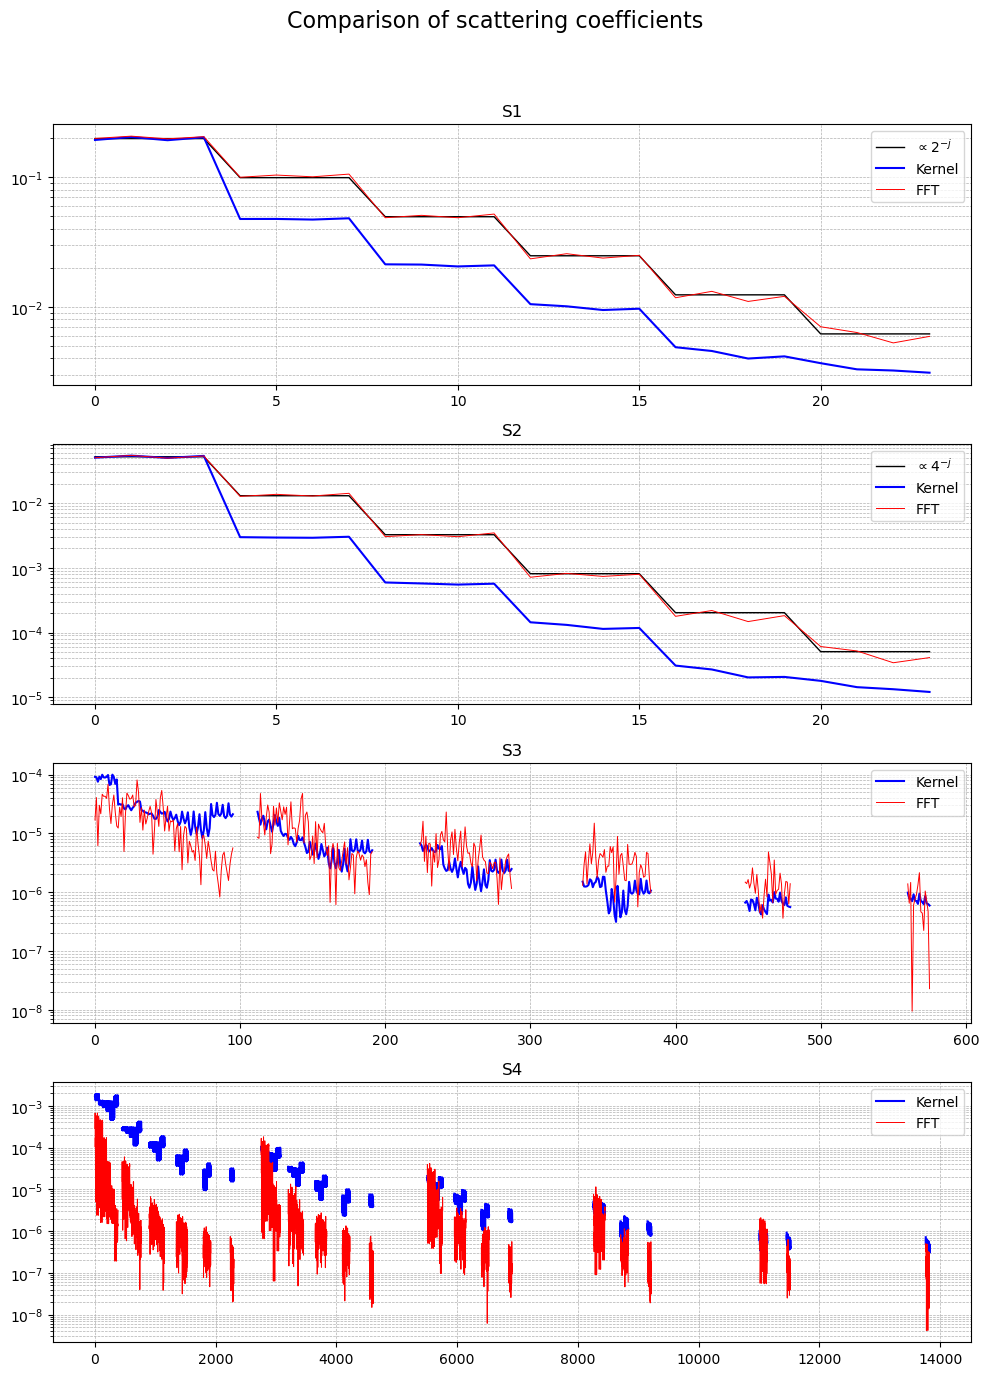

W1  0 tensor([[[ 0.0000e+00+0.0000e+00j, -0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j, -0.0000e+00+0.0000e+00j,
           0.0000e+00+0.0000e+00j],
         [ 0.0000e+00+0.0000e+00j, -6.3165e-03-1.5314e-02j,
          -3.4919e-02-6.5463e-02j, -7.0603e-03-1.4986e-02j,
           0.0000e+00+0.0000e+00j],
         [ 0.0000e+00+0.0000e+00j,  4.2902e-02+1.0532e-03j,
           1.8617e-01+0.0000e+00j,  4.2902e-02-1.0532e-03j,
           0.0000e+00+0.0000e+00j],
         [ 0.0000e+00+0.0000e+00j, -7.0603e-03+1.4986e-02j,
          -3.4919e-02+6.5463e-02j, -6.3165e-03+1.5314e-02j,
           0.0000e+00+0.0000e+00j],
         [-0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
           0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j]],

        [[ 0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j],
         [-0.0000e+00+0.0000e+00j,  1.7156e-02+4.2115e-0

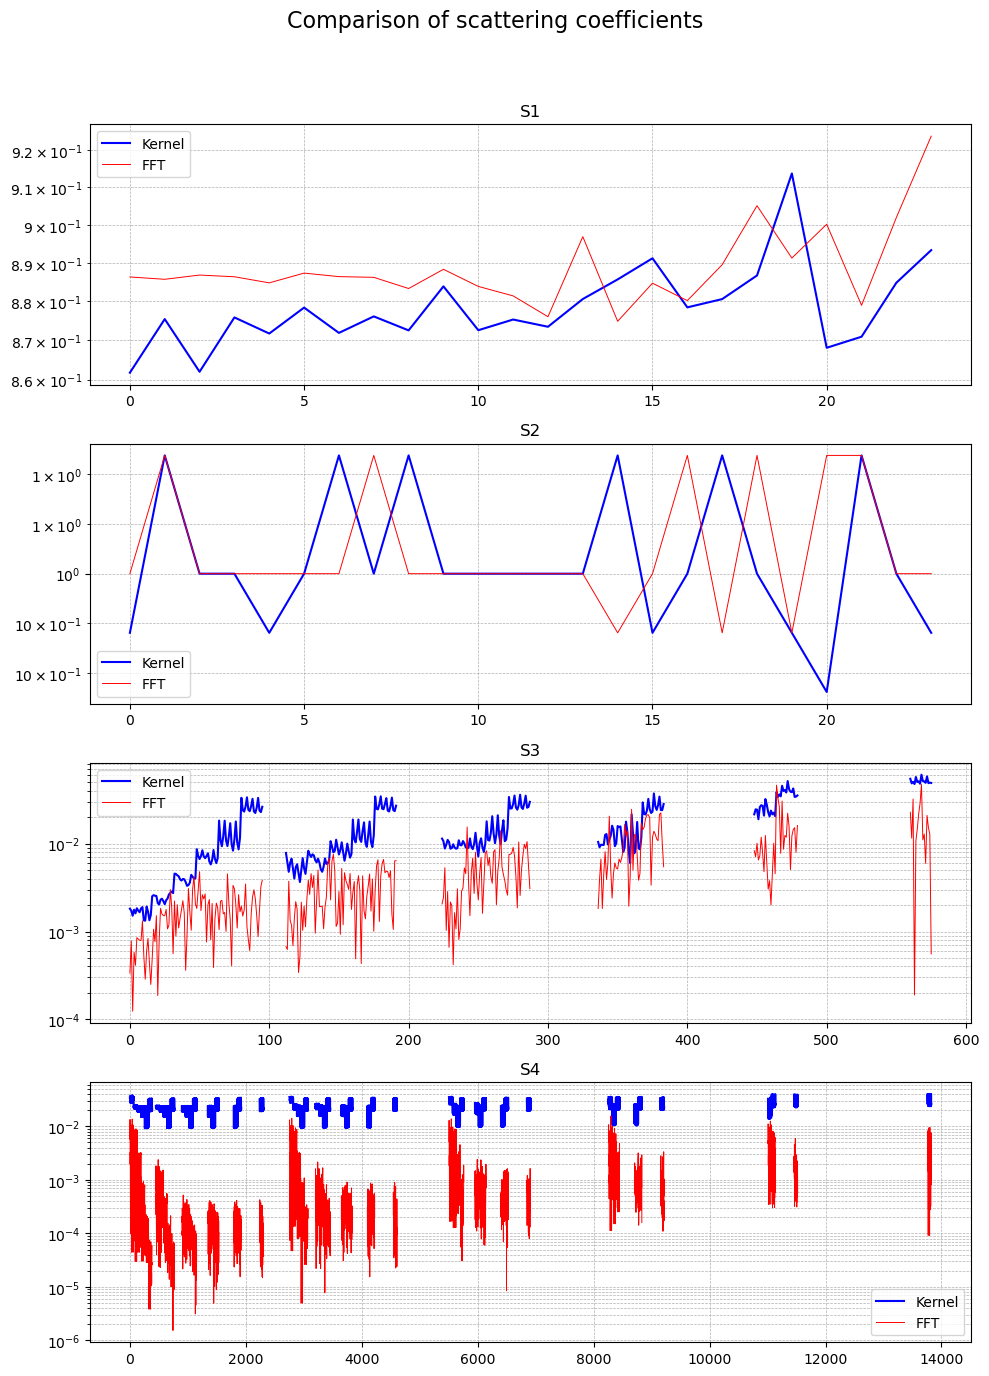

In [4]:
# set random seed for reproducibility
np.random.seed(0)

batch = 1 # no batch_mean param implemented in current this normalization branch
size = 256

noise = np.random.randn(batch, 1, size, size)

compare_kernel_fft(noise, norm="vanilla", plot_slopes=True)
compare_kernel_fft(noise, norm=None, plot_slopes=False)

### Check with simulation data

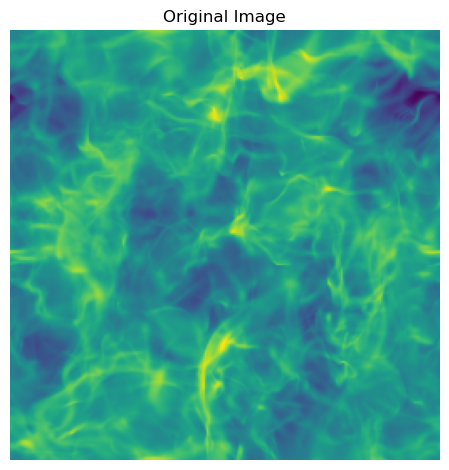

In [5]:
# Image loading
im = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:, None, :, :] # [Nb, Nc, Nx, Ny]

# Visualize loaded data
plt.imshow(im[0, 0, :, :])
plt.title("Original Image")
plt.axis('off')
plt.tight_layout()
plt.show()

W1  0 tensor([[[ 0.0000e+00+0.0000e+00j, -0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j, -0.0000e+00+0.0000e+00j,
           0.0000e+00+0.0000e+00j],
         [ 0.0000e+00+0.0000e+00j, -6.3165e-03-1.5314e-02j,
          -3.4919e-02-6.5463e-02j, -7.0603e-03-1.4986e-02j,
           0.0000e+00+0.0000e+00j],
         [ 0.0000e+00+0.0000e+00j,  4.2902e-02+1.0532e-03j,
           1.8617e-01+0.0000e+00j,  4.2902e-02-1.0532e-03j,
           0.0000e+00+0.0000e+00j],
         [ 0.0000e+00+0.0000e+00j, -7.0603e-03+1.4986e-02j,
          -3.4919e-02+6.5463e-02j, -6.3165e-03+1.5314e-02j,
           0.0000e+00+0.0000e+00j],
         [-0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
           0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j]],

        [[ 0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j],
         [-0.0000e+00+0.0000e+00j,  1.7156e-02+4.2115e-0

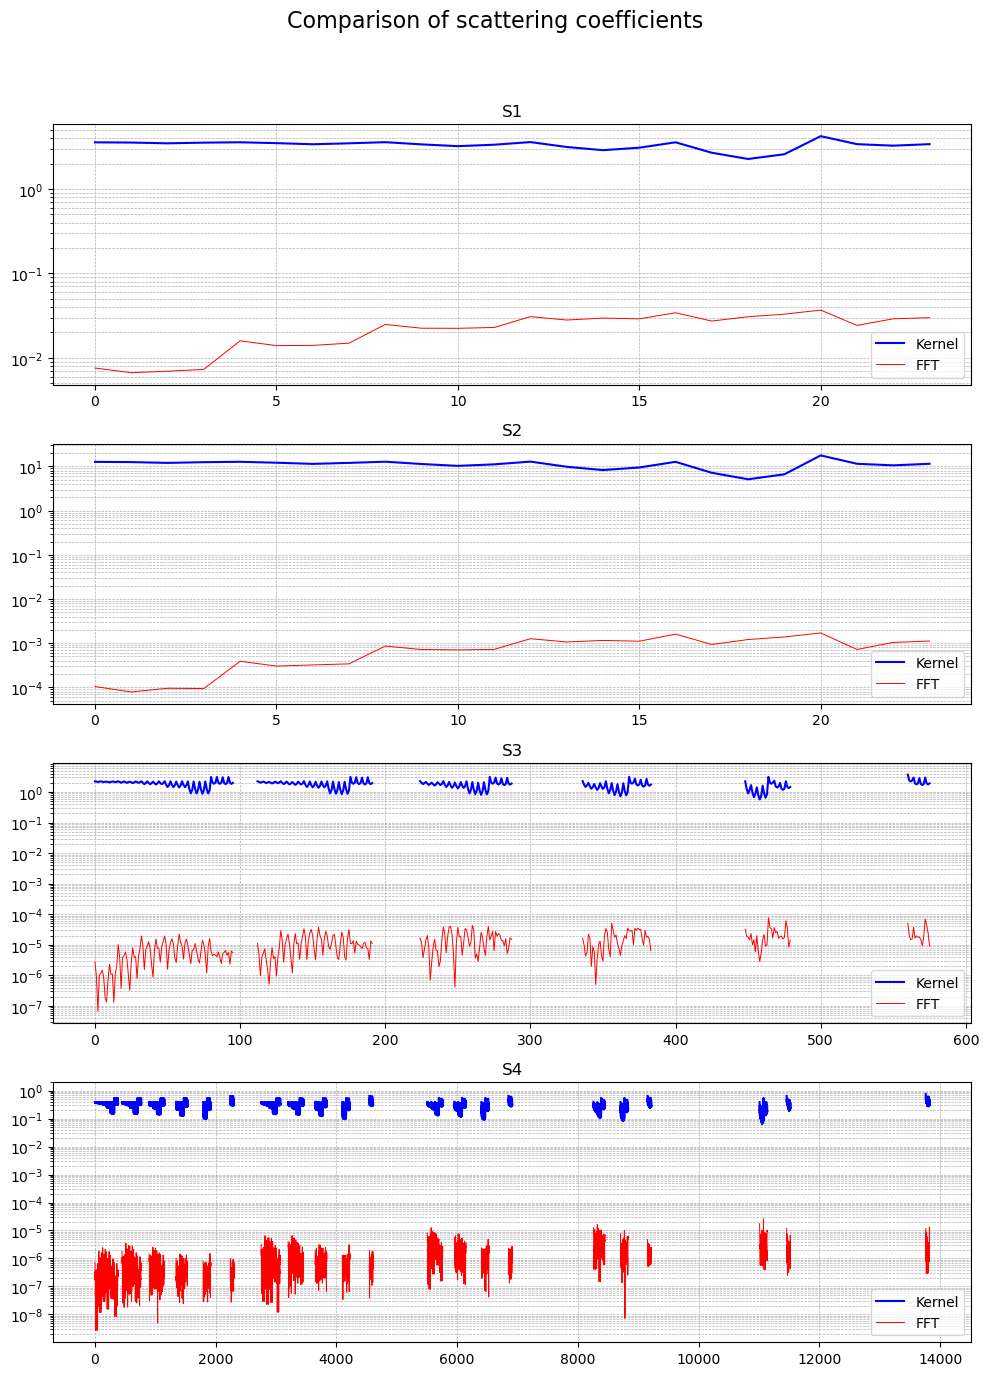

W1  0 tensor([[[ 0.0000e+00+0.0000e+00j, -0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j, -0.0000e+00+0.0000e+00j,
           0.0000e+00+0.0000e+00j],
         [ 0.0000e+00+0.0000e+00j, -6.3165e-03-1.5314e-02j,
          -3.4919e-02-6.5463e-02j, -7.0603e-03-1.4986e-02j,
           0.0000e+00+0.0000e+00j],
         [ 0.0000e+00+0.0000e+00j,  4.2902e-02+1.0532e-03j,
           1.8617e-01+0.0000e+00j,  4.2902e-02-1.0532e-03j,
           0.0000e+00+0.0000e+00j],
         [ 0.0000e+00+0.0000e+00j, -7.0603e-03+1.4986e-02j,
          -3.4919e-02+6.5463e-02j, -6.3165e-03+1.5314e-02j,
           0.0000e+00+0.0000e+00j],
         [-0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
           0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j]],

        [[ 0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j,  0.0000e+00+0.0000e+00j,
          -0.0000e+00+0.0000e+00j],
         [-0.0000e+00+0.0000e+00j,  1.7156e-02+4.2115e-0

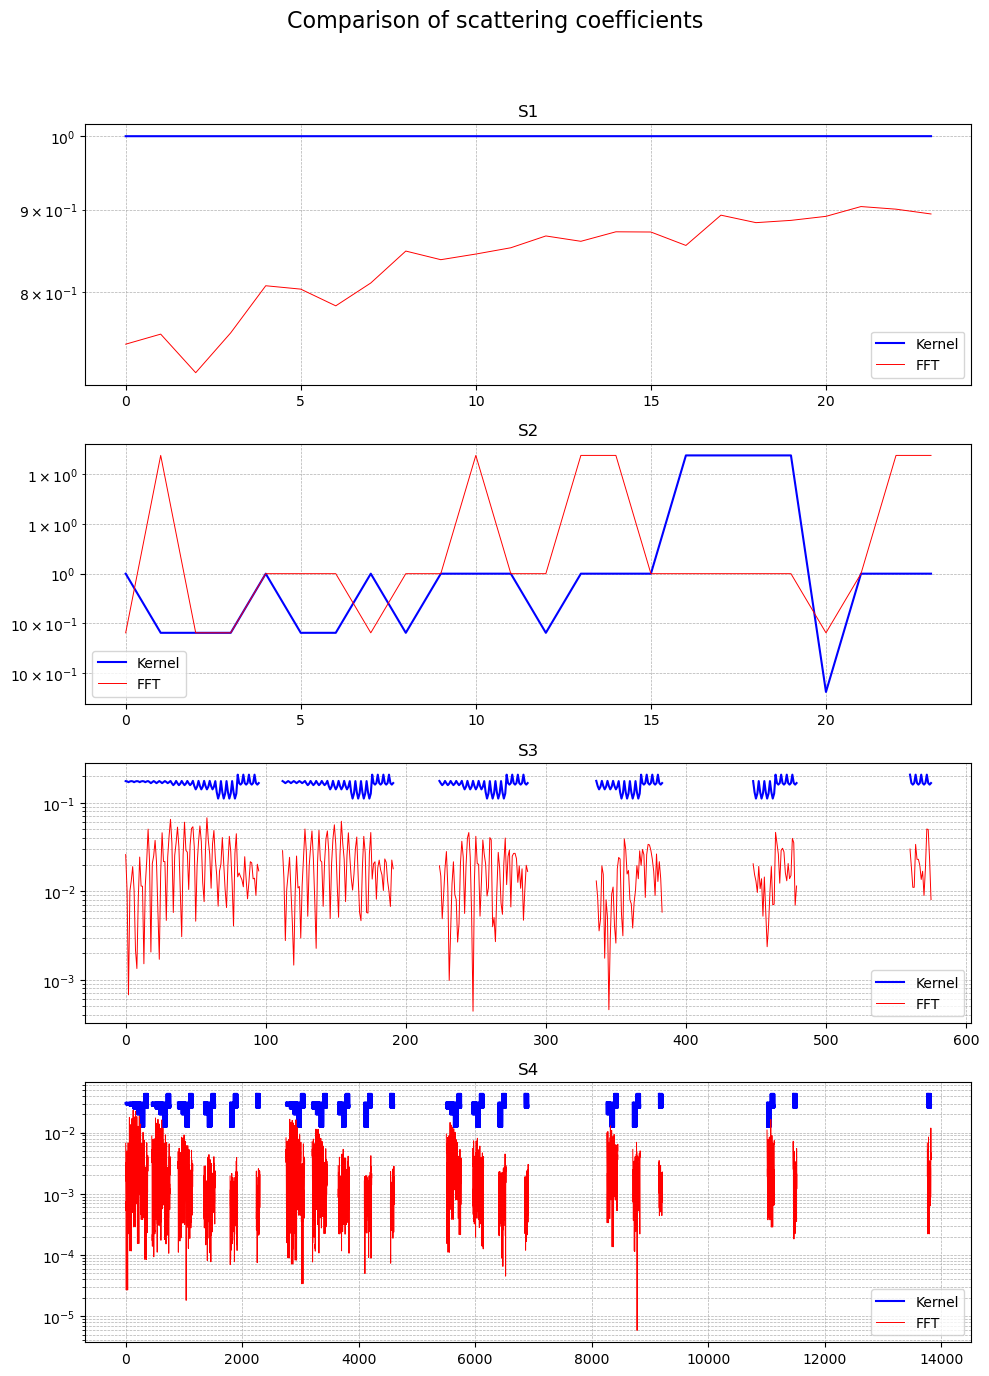

In [6]:
im_mono_channel = im[0, 0, :, :]

compare_kernel_fft(im_mono_channel, norm="vanilla")
compare_kernel_fft(im_mono_channel, norm=None)